In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [2]:
class BatsmanState(TypedDict):
    runs:int
    balls:int
    fours:int
    sixes:int

    sr:float
    bpb:float
    bp:float
    summary:str

In [3]:
def cal_sr(state:BatsmanState):
    sr = (state["runs"]/state["balls"])*100

    return {'sr':sr}


In [4]:
def cal_bpb(state:BatsmanState):
    bpb = (state["fours"]+state["sixes"])/state["balls"]

    return {"bpb":bpb}

In [5]:
def cal_bp(state:BatsmanState):
    bp = ((state["fours"]*4+state["sixes"]*6)/state["runs"]) * 100

    return {"bp":bp}

In [6]:
def summary(state:BatsmanState):
    summary = f"Batsman scored {state['runs']} runs in {state['balls']} balls with a strike rate of {state['sr']:.2f} and boundary percentage of {state['bp']:.2f}%."
    return {"summary":summary}




In [7]:

# Nodes
# Define your graph

graph = StateGraph(BatsmanState)

# nodes

graph.add_node('cal_sr',cal_sr)
graph.add_node('cal_bpb',cal_bpb)
graph.add_node('cal_bp',cal_bp)
graph.add_node('summary',summary)


# edges

graph.add_edge(START,'cal_sr')
graph.add_edge(START,'cal_bpb')
graph.add_edge(START,'cal_bp')
graph.add_edge('cal_sr','summary')
graph.add_edge('cal_bpb','summary')
graph.add_edge('cal_bp','summary')
graph.add_edge('summary',END)


# compile

workflow = graph.compile()




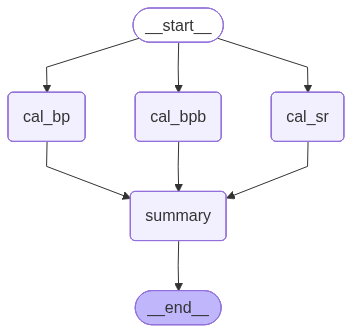

In [8]:
workflow

In [9]:
initial_state = {"runs": 160, "balls": 80, "fours": 10, "sixes": 5}
result = workflow.invoke(initial_state)
print(result["summary"])

Batsman scored 160 runs in 80 balls with a strike rate of 200.00 and boundary percentage of 43.75%.
